# ☕ Cafe Sales Data Analysis

## Project Overview

This project analyzes a café sales dataset to understand customer purchasing behavior, product performance, revenue trends, and payment preferences.

The project follows the complete data analytics workflow:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insights

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

---


## Dataset Information

The dataset contains **10,000 café transactions** collected during the year 2023.

### Features

| Column | Description |
|---------|-------------|
| Transaction ID | Unique transaction identifier |
| Item | Product purchased |
| Quantity | Number of items purchased |
| Price Per Unit | Price of one item |
| Total Spent | Total bill amount |
| Payment Method | Payment mode used |
| Location | In-store or Takeaway |
| Transaction Date | Date of transaction |

1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

2: Load Dataset

In [2]:
df = pd.read_excel(
    r"C:\Users\Parth\OneDrive\Desktop\DA projects\clean_cafe_sales_correct.xlsx"
) 

## Dataset Overview

This section provides a quick understanding of the dataset structure, including dimensions, columns, data types, and summary statistics.

3: Dataset Overview

In [24]:
# Dataset Shape
print(df.shape)

# first five rows
print(df.head())

# Last five rows
print(df.tail())

# Dataset Shape
print(df.shape)

# Column Names
print(df.columns)

# Data types
print(df.dtypes)

# General Information
print(df.info())

# Statistical summary
print(df.describe())

(10000, 8)
  Transaction ID    Item  Quantity  Price Per Unit  Total Spent  \
0    TXN_1961373  Coffee       2.0             2.0          4.0   
1    TXN_4977031    Cake       4.0             3.0         12.0   
2    TXN_4271903  Cookie       4.0             1.0          NaN   
3    TXN_7034554   Salad       2.0             5.0         10.0   
4    TXN_3160411  Coffee       2.0             2.0          4.0   

   Payment Method  Location Transaction Date  
0     Credit Card  Takeaway       2023-09-08  
1            Cash  In-store       2023-05-16  
2     Credit Card  In-store       2023-07-19  
3             NaN       NaN       2023-04-27  
4  Digital Wallet  In-store       2023-06-11  
     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9996    TXN_9659401       NaN       3.0             NaN          3.0   
9997    TXN_5255387    Coffee       4.0             2.0          8.0   
9998    TXN_7695

### Initial Observations

- The dataset contains 10,000 transaction records and 8 columns.
- Data types are correctly assigned after the cleaning process.
- Numeric columns (Quantity, Price Per Unit, and Total Spent) are stored as numeric values.
- Transaction Date has been successfully converted to datetime format.
- Missing values remain in several columns, representing genuinely unavailable information rather than incorrect values.
- The dataset is ready for further validation and exploratory data analysis.

## Data Quality Assessment

After the initial cleaning process in Excel, the dataset was validated to identify missing values, duplicate records, unique values, and overall data quality before performing exploratory data analysis.

4: Verify Cleaning

In [22]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print(df.duplicated().sum())

# Unique values
print(df.nunique())

# Sample records
print(df.sample(10))

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64
0
Transaction ID      10000
Item                    8
Quantity                5
Price Per Unit          6
Total Spent            17
Payment Method          3
Location                2
Transaction Date      365
dtype: int64
     Transaction ID    Item  Quantity  Price Per Unit  Total Spent  \
9915    TXN_9400245   Salad       1.0             5.0          5.0   
5200    TXN_5566774     Tea       3.0             1.5          4.5   
2380    TXN_1248167     NaN       1.0             4.0          4.0   
3423    TXN_1050083    Cake       5.0             3.0         15.0   
1687    TXN_9465300     Tea       2.0             1.5          3.0   
1049    TXN_7201724   Salad       1.0             5.0          5.0   
3712    TXN_2567222  Coffee       3.0             2.0          6.0   
7603

### Missing Values Analysis

The dataset still contains missing values after the cleaning process. These missing values were retained because they represent genuinely unavailable information rather than data that can be reliably inferred.

- Transaction ID contains no missing values.
- Item, Payment Method, Location, and Transaction Date contain genuine missing records.
- Numeric columns (Quantity, Price Per Unit, and Total Spent) contain missing values that will be evaluated during data validation. Values will only be imputed when they can be derived with complete certainty; otherwise, they will remain missing.

### Duplicate Records

No duplicate rows were identified in the dataset. Therefore, no records were removed during the duplicate check.


In [31]:
# Validate Total spent

Validation= df.copy()

Validation["Calculated_Total"]= (
    Validation["Quantity"] * Validation["Price Per Unit"]
)

Validation["Is_Valid"]= (
    Validation["Calculated_Total"] == Validation["Total Spent"]
)

Validation[["Quantity",
           "Price Per Unit",
           "Total Spent",
           "Calculated_Total",
           "Is_Valid"]].head()

,Quantity,Price Per Unit,Total Spent,Calculated_Total,Is_Valid
0,2.0,2.0,4.0,4.0,True
1,4.0,3.0,12.0,12.0,True
2,4.0,1.0,NaN,4.0,False
3,2.0,5.0,10.0,10.0,True
4,2.0,2.0,4.0,4.0,True


In [33]:
Validation["Is_Valid"].value_counts(dropna=False)

Is_Valid
True     8544
False    1456
Name: count, dtype: int64

📌 Markdown Cell

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand sales patterns, customer purchasing behavior, payment preferences, and business performance through statistical summaries and visualizations.

In [ ]:
1️⃣ Most Sold Items

In [36]:
# Number of transactions by item

Item_Count= df["Item"].value_counts()

print(Item_Count)

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64


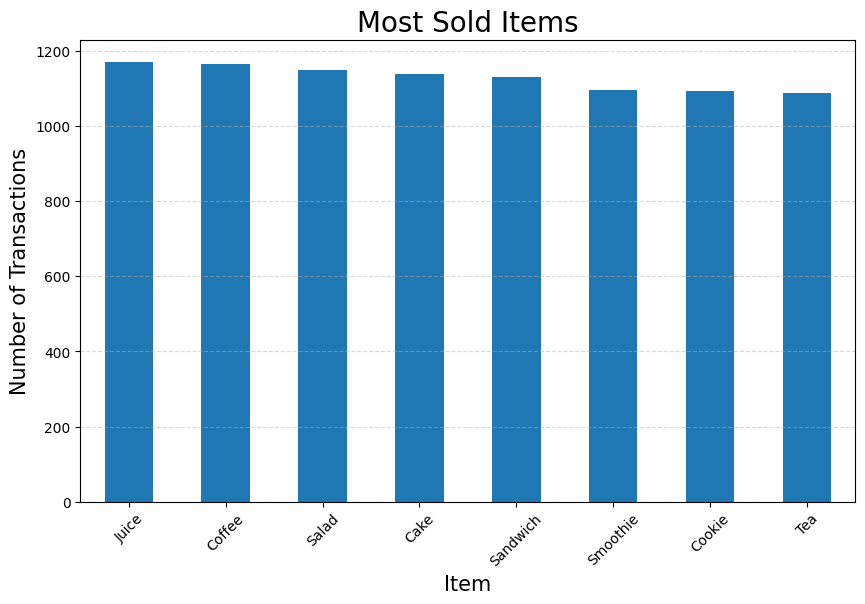

In [57]:
### Visualization

plt.figure(figsize=(10,6))

Item_Count.plot(kind="bar")

plt.title("Most Sold Items", fontsize=20)
plt.xlabel("Item", fontsize=15)
plt.ylabel("Number of Transactions", fontsize=15)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Business Insight

- Juice is the most frequently purchased item in the café.
- Coffee is the second most popular product.
- Tea and Cookie have the lowest number of transactions among the available products.
- Overall, the transaction counts across all menu items are relatively balanced, indicating that customer demand is distributed across multiple products rather than being concentrated on a single item.ces.

2️⃣ Total Revenue by Item

In [58]:
revenue_item= df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

print(revenue_item)

Item
Salad       16605.0
Sandwich    12956.0
Smoothie    12556.0
Juice        9984.0
Cake         9933.0
Coffee       6784.0
Tea          4735.5
Cookie       3070.0
Name: Total Spent, dtype: float64


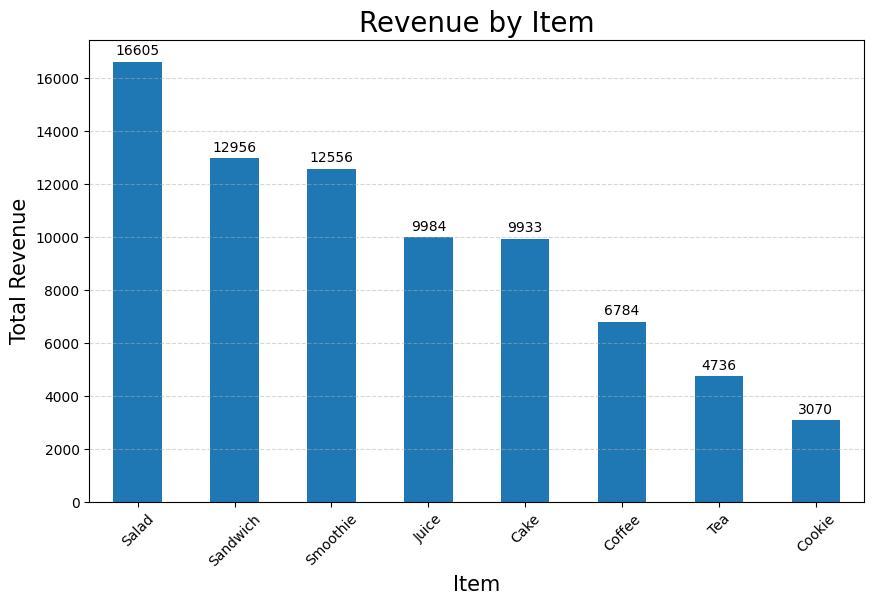

In [74]:
### Visualization

plt.figure(figsize=(10,6))

ax= revenue_item.plot(kind="bar")

plt.title("Revenue by Item", fontsize=20)
plt.xlabel("Item", fontsize=15)
plt.ylabel("Total Revenue", fontsize=15)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.show()

### Business Insight

- Salad generated the highest total revenue among all menu items.
- Sandwich and Smoothie were the second and third highest revenue-generating products.
- Coffee, Tea, and Cookie contributed the least revenue.
- Although Juice had the highest number of transactions, it did not generate the highest revenue. This indicates that higher-priced items such as Salad and Sandwich contribute more to overall revenue.

3️⃣ Payment Method Analysis

In [61]:
payment= df["Payment Method"].value_counts()

print(payment)

Payment Method
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64


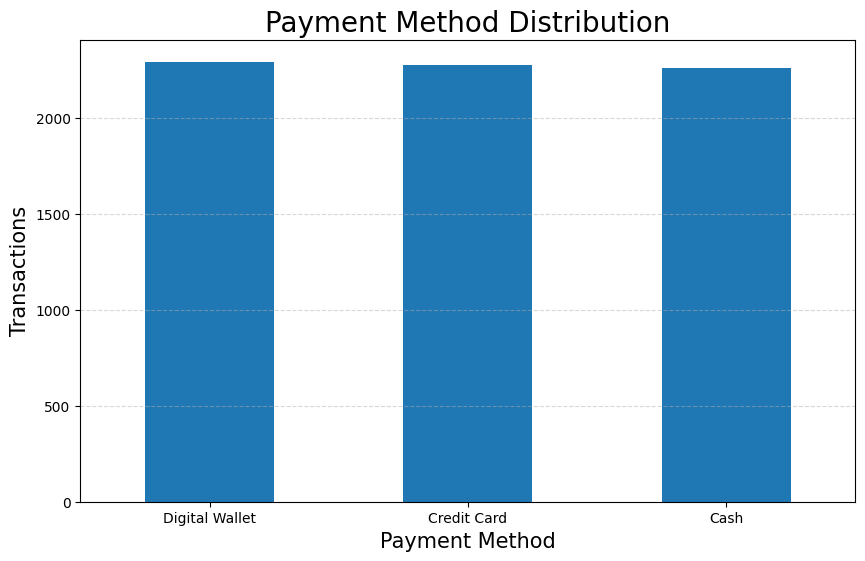

In [80]:
### Visualization

plt.figure(figsize=(10,6))

payment.plot(kind= "bar")

plt.title("Payment Method Distribution", fontsize= 20)
plt.xlabel("Payment Method", fontsize= 15)
plt.ylabel("Transactions", fontsize= 15)

plt.xticks(rotation= 0)
plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

### Business Insight

- Customers use all three payment methods (Digital Wallet, Credit Card, and Cash) at nearly the same frequency.
- No single payment method dominates customer transactions, indicating that customers are comfortable using multiple payment options.
- The balanced distribution suggests that the café should continue supporting all available payment methods to ensure customer convenience.
- Maintaining reliable digital and cash payment facilities can help provide a smooth customer experience without favoring one payment method over another.
- Digital Wallet was the most frequently used payment method, followed closely by Credit Card and Cash. However, the difference is relatively small, indicating balanced customer payment preferences.

4️⃣ Sales by Location

In [75]:
location= df.groupby("Location")["Total Spent"].sum()

print(location)

Location
In-store    25906.0
Takeaway    25229.5
Name: Total Spent, dtype: float64


In [81]:
### Visualization

plt.figure(figsize=(10,6))

location.plot(kind= "bar")

plt.title("Revenue by Location")
plt.xlabel("Location")
plt.ylabel("Revenue")

plt.xticks(rotation= 0)
plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

### Business Insight

- In-store purchases generated a total revenue of **25,906.0**, while takeaway purchases generated **25,229.5**.
- Revenue from both sales channels is nearly equal, indicating that customers use both in-store and takeaway services almost equally.
- In-store sales contributed slightly more revenue than takeaway sales, suggesting a small preference for dining at the café.
- Since both channels contribute significantly to overall revenue, the café should continue investing in both in-store customer experience and efficient takeaway services.

5️⃣ Monthly Sales Trend

In [84]:
# Create Month column
df["Month"] = df["Transaction Date"].dt.month_name()

# Define correct month order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# Convert Month to ordered categorical
df["Month"] = pd.Categorical(
    df["Month"],
    categories=month_order,
    ordered=True
)

# Monthly revenue
monthly_sales = df.groupby("Month", observed=True)["Total Spent"].sum()

print(monthly_sales)

Month
January      6845.0
February     6304.0
March        6822.0
April        6730.5
May          6674.0
June         7071.5
July         6574.0
August       6904.0
September    6501.5
October      7040.5
November     6532.5
December     6801.0
Name: Total Spent, dtype: float64


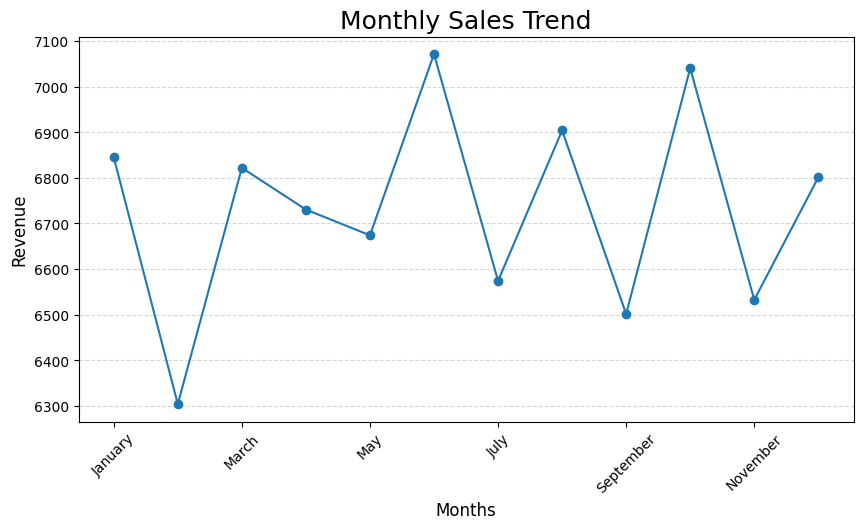

In [85]:
### Visulaization

plt.figure(figsize=(10,5))

monthly_sales.plot(kind= "line", marker="o")

plt.title("Monthly Sales Trend", fontsize= 18)
plt.xlabel("Months", fontsize= 12)
plt.ylabel("Revenue", fontsize= 12)

plt.xticks(rotation= 45)
plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

### Business Insight

- Monthly revenue remained relatively stable throughout the year, with only moderate fluctuations.
- June recorded the highest revenue, indicating a peak sales period.
- February generated the lowest revenue among all months.
- The absence of extreme spikes or drops suggests consistent customer demand throughout the year.
- Understanding monthly sales patterns can help the café plan inventory, staffing, and promotional campaigns more effectively.

6️⃣ Average Order Value

In [89]:
print("Total Revenue:", df["Total Spent"].sum())
print("Average Order Value:", df["Total Spent"].mean())

Total Revenue: 84763.5
Average Order Value: 8.924352495262161


### Business Insight

- The café generated a total revenue of **84,763.50** during the analysis period.
- The average order value (AOV) is **8.92** per transaction.
- This indicates that, on average, customers spend approximately **8.92** in each completed purchase.
- Monitoring the average order value helps evaluate customer spending behavior and can support pricing, promotional, and product bundling strategies.

7️⃣ Quantity Distribution

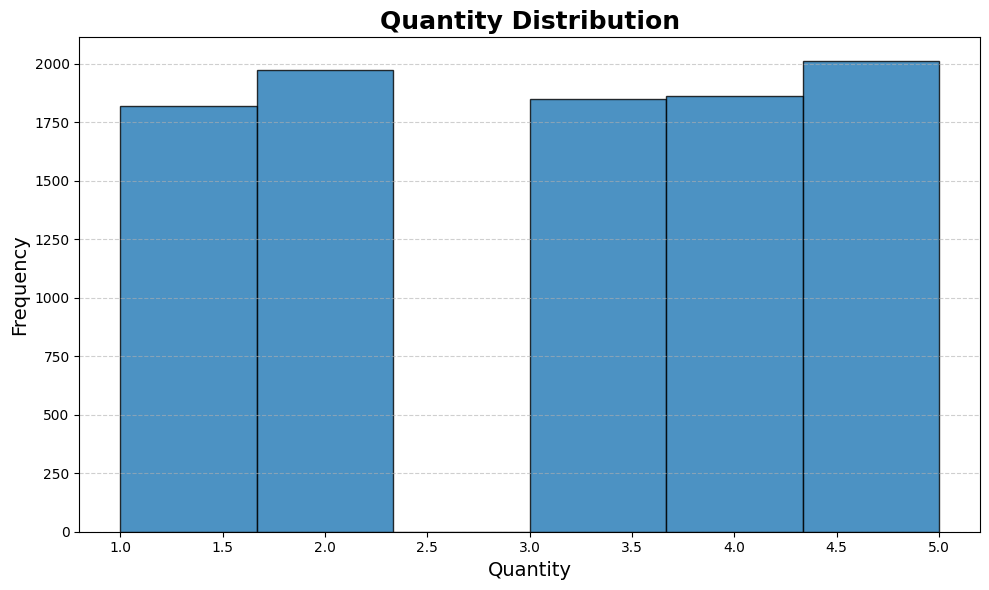

In [97]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Quantity"].dropna(),
    bins= 6,
    edgecolor= "black",
    alpha= 0.8
)

plt.title("Quantity Distribution", fontsize= 18, fontweight= "bold")
plt.xlabel("Quantity", fontsize= 14)
plt.ylabel("Frequency", fontsize= 14)

plt.grid(axis= "y", linestyle= "--", alpha= 0.6)

plt.tight_layout()
plt.show()

### Business Insight

### Business Insight

- Most customer purchases involve **2 to 5 items** per transaction.
- Quantities are fairly evenly distributed, indicating that customers purchase varying amounts rather than consistently buying a single quantity.
- Transactions with **5 items** appear slightly more frequently, suggesting that customers often purchase multiple products in one visit.
- Understanding quantity distribution can help the café estimate inventory requirements and optimize stock levels.

8️⃣ Price Distribution

In [98]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Price Per Unit"].dropna(),
    bins= 6,
    edgecolor= "black",
    alpha= 0.8
)

plt.title("Price Per Unit", fontsize= 18, fontweight= "bold")
plt.xlabel("Price", fontsize= 14)
plt.ylabel("Frequency", fontsize= 14)

plt.grid(axis= "y", linestyle= "--", alpha= 0.6)

plt.tight_layout()
plt.show()

### Business Insight

- Product prices range from **$1.00 to $5.00** per unit.
- Most products are priced between **$3.00 and $4.00**, indicating a standardized pricing strategy.
- Lower-priced ($1.00–$2.00) and higher-priced ($5.00) products occur less frequently than mid-priced items.
- A limited number of price points simplifies pricing for customers and helps maintain pricing consistency.

9️⃣ Total Spent Distribution

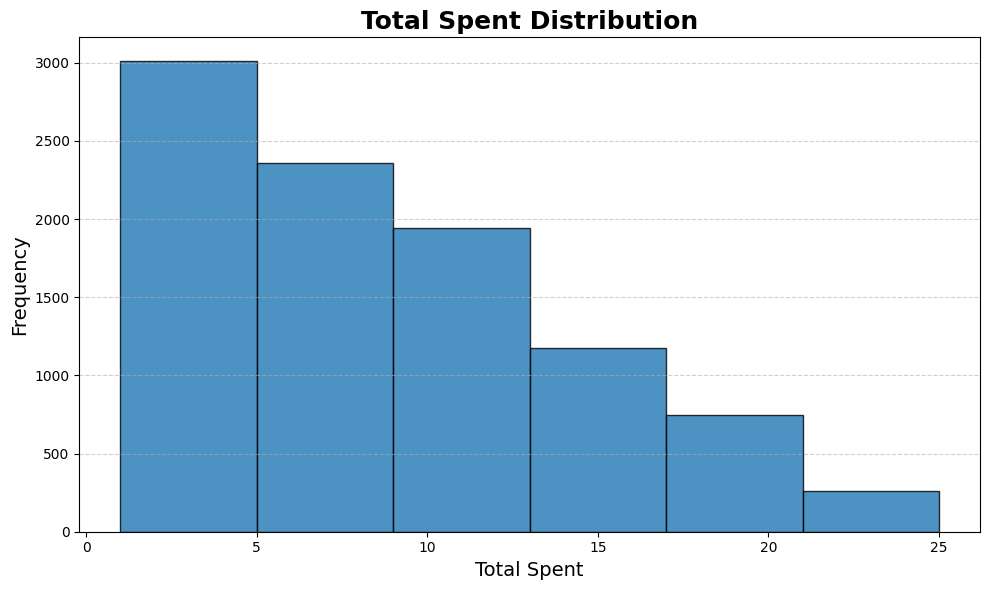

In [101]:
plt.figure(figsize= (10,6))

plt.hist(
    df["Total Spent"].dropna(),
    bins= 6,
    edgecolor= "black",
    alpha=0.8
)

plt.title("Total Spent Distribution", fontsize= 18, fontweight= "bold")
plt.xlabel("Total Spent", fontsize= 14)
plt.ylabel("Frequency", fontsize= 14)

plt.grid(axis= "y", linestyle= "--", alpha= 0.6)

plt.tight_layout()
plt.show()

## Overall Business Insights

1. Juice is the most frequently purchased product, indicating high customer demand.

2. Salad generates the highest total revenue, showing that higher-priced products contribute more to overall sales than the most frequently sold items.

3. Digital Wallet, Credit Card, and Cash are used almost equally, indicating balanced customer payment preferences.

4. In-store sales generate slightly higher revenue than takeaway sales, although both sales channels contribute almost equally.

5. Monthly revenue remains relatively stable throughout the year, with June recording the highest sales and February the lowest.

6. The café generated a total revenue of **$84,763.50**, with an average order value of **$8.92** per transaction.

7. Product prices range from **$1.00 to $5.00**, reflecting a simple and consistent pricing strategy.

8. Most customer transactions involve modest spending, with relatively few high-value purchases.

## Conclusion

This project analyzed a café sales dataset using Python and Pandas to explore customer purchasing behavior, product performance, revenue trends, and payment preferences.

The analysis showed that while Juice is the most frequently purchased item, Salad contributes the highest revenue. Customer spending is consistent throughout the year, and both in-store and takeaway channels contribute almost equally to overall revenue. Payment methods are well balanced, indicating that customers are comfortable using multiple payment options.

The insights from this analysis can support business decisions related to inventory management, pricing strategies, promotional campaigns, and customer service improvements. The cleaned dataset is now ready for advanced analysis using SQL and interactive dashboard development in Power BI.

# Executive Summary

The following key performance indicators (KPIs) provide a quick overview of the café's sales performance.

In [3]:
# Key Performance Indicators (KPIs)

total_transactions = len(df)
total_revenue = df["Total Spent"].sum()
average_order = df["Total Spent"].mean()
unique_products = df["Item"].nunique()
payment_methods = df["Payment Method"].nunique()
sales_channels = df["Location"].nunique()

print(f"Total Transactions : {total_transactions:,}")
print(f"Total Revenue      : ${total_revenue:,.2f}")
print(f"Average Order Value: ${average_order:.2f}")
print(f"Products Sold      : {unique_products}")
print(f"Payment Methods    : {payment_methods}")
print(f"Sales Channels     : {sales_channels}")

Total Transactions : 10,000
Total Revenue      : $84,763.50
Average Order Value: $8.92
Products Sold      : 8
Payment Methods    : 3
Sales Channels     : 2
